In [22]:
from TARFlow import TARFlow
from tarflow_train import TrainConfig, build_model, Trainer
from tarflow_sample import SampleConfig, Sampler, load_model
from data import get_mnist_loaders

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from collections import Counter

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

In [23]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

# Consistent figure style throughout
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#0f0f0f',
    'text.color':       '#e8e8e8',
    'axes.labelcolor':  '#e8e8e8',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'axes.edgecolor':   '#333333',
    'grid.color':       '#222222',
    'font.family':      'monospace',
})

PyTorch 2.9.1+cpu  |  device: cpu


In [24]:
cfg = TrainConfig(
    # Paths
    data_dir         = './data',
    output_dir       = './runs',

    # Image / patch geometry — back to full 28×28
    img_size         = 16,
    channel_size     = 1,
    patch_size       = 4,

    # Model architecture — wider and deeper
    channels         = 128,
    blocks           = 4,
    layers_per_block = 4,
    nvp              = True,
    unconditional    = False,

    # Optimiser — more epochs, smaller batch for better gradient estimates
    epochs           = 50,
    batch_size       = 256,
    lr               = 1e-4,
    weight_decay     = 1e-4,
    grad_clip        = 1.0,

    # Noise augmentation
    noise_std        = 0.05,
    noise_type       = 'gaussian',

    # CFG training
    drop_label       = 0.1,

    # Logging
    log_freq         = 200,

    # Checkpoint
    resume           = '',
)

train_loader, val_loader = get_mnist_loaders(cfg)

print(f'Training batches : {len(train_loader)}')
print(f'Val batches      : {len(val_loader)}')
print(f'Batch shape      : {next(iter(train_loader))[0].shape}')
print(f'Num patches      : {cfg.num_patches}  ({cfg.img_size//cfg.patch_size}×{cfg.img_size//cfg.patch_size} grid)')
print(f'Patch dim        : {cfg.patch_dim}  ({cfg.channel_size}×{cfg.patch_size}²)')

Training batches : 234
Val batches      : 40
Batch shape      : torch.Size([256, 1, 16, 16])
Num patches      : 16  (4×4 grid)
Patch dim        : 16  (1×4²)


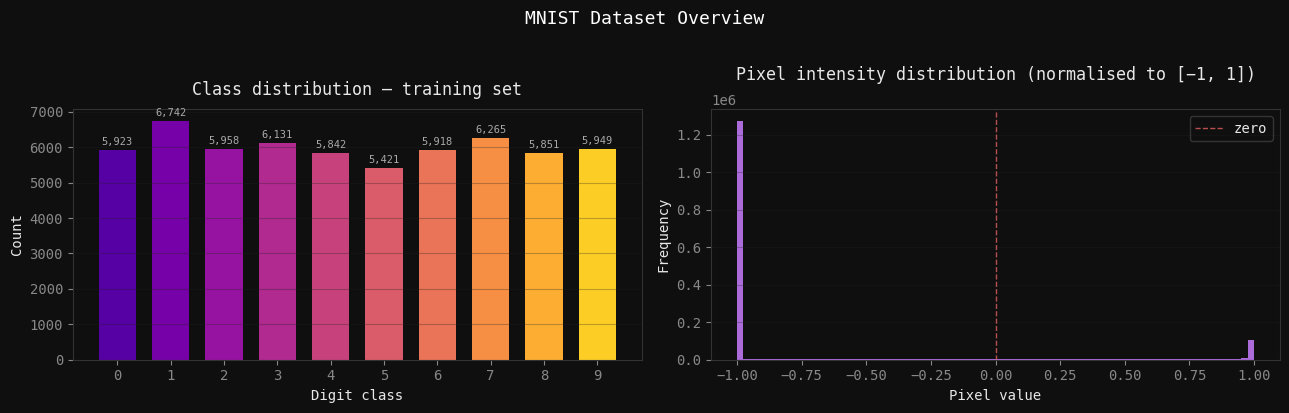

Total training images : 60,000
Total val images      : 10,000
Image shape           : (1, 16, 16)


In [25]:
# Collect all labels quickly
all_labels  = train_loader.dataset.targets.numpy()
class_names = [str(i) for i in range(10)]
counts      = Counter(all_labels.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0f0f0f')

# --- Class distribution bar chart ---
ax = axes[0]
bar_colors = plt.cm.plasma(np.linspace(0.15, 0.9, 10))
bars = ax.bar(class_names, [counts[i] for i in range(10)], color=bar_colors, width=0.7)
ax.set_title('Class distribution — training set', color='#e8e8e8', pad=10)
ax.set_xlabel('Digit class')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
for bar, cnt in zip(bars, [counts[i] for i in range(10)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{cnt:,}', ha='center', va='bottom', fontsize=7.5, color='#aaaaaa')

# --- Pixel intensity histogram ---
ax = axes[1]
# Sample 2000 images for the histogram
sample_imgs = train_loader.dataset.data[:2000].float() / 255.0
sample_imgs = (sample_imgs - 0.5) / 0.5   # match the [-1,1] normalisation
pixel_vals  = sample_imgs.numpy().flatten()
ax.hist(pixel_vals, bins=80, color='#c77dff', alpha=0.85, edgecolor='none')
ax.set_title('Pixel intensity distribution (normalised to [−1, 1])', color='#e8e8e8', pad=10)
ax.set_xlabel('Pixel value')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=0, color='#ff6b6b', linewidth=1, linestyle='--', alpha=0.7, label='zero')
ax.legend(framealpha=0.2)

plt.suptitle('MNIST Dataset Overview', color='#ffffff', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total training images : {len(train_loader.dataset):,}')
print(f'Total val images      : {len(val_loader.dataset):,}')
print(f'Image shape           : {tuple(train_loader.dataset[0][0].shape)}')

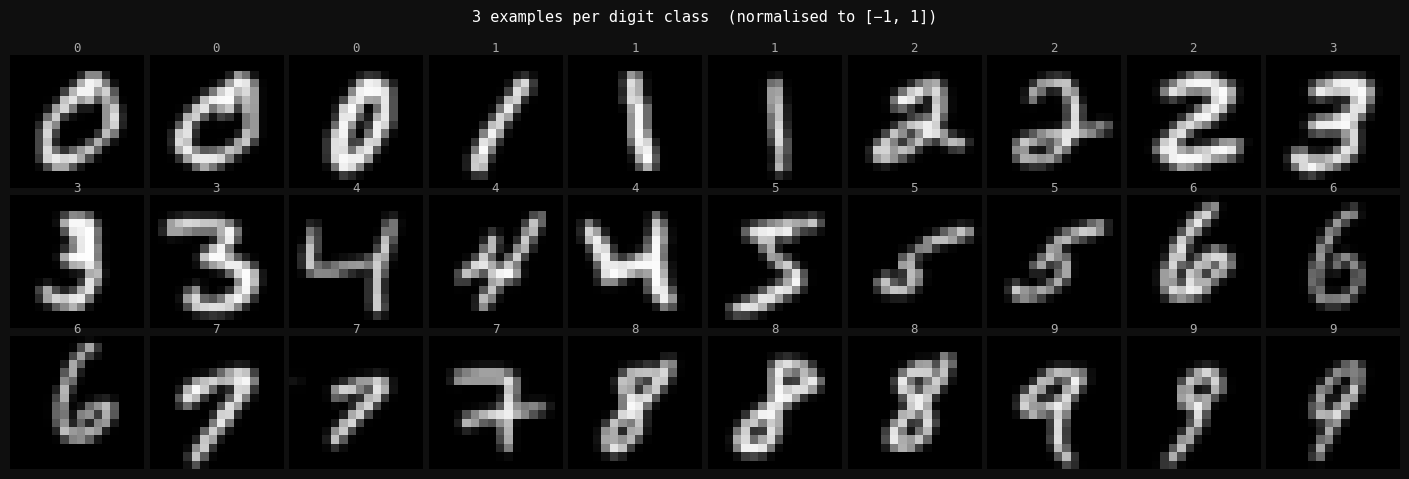

In [26]:
def show_grid(images, titles=None, nrow=10, figsize=(14, 2.2), suptitle=None, cmap='gray'):
    """
    Display a grid of (N, C, H, W) image tensors.
    Handles both [-1,1] normalised and [0,1] images.
    """
    imgs = images.cpu().float()
    # Map [-1,1] → [0,1] if needed
    if imgs.min() < -0.01:
        imgs = (imgs + 1) / 2
    imgs = imgs.clamp(0, 1)

    n    = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol

    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    fig.patch.set_facecolor('#0f0f0f')
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            img = imgs[i]
            if img.shape[0] == 1:
                ax.imshow(img[0].numpy(), cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(img.permute(1, 2, 0).numpy())
            if titles is not None and i < len(titles):
                ax.set_title(str(titles[i]), color='#aaaaaa', fontsize=9, pad=2)

    if suptitle:
        fig.suptitle(suptitle, color='#ffffff', fontsize=11, y=1.03)
    plt.tight_layout(pad=0.3)
    plt.show()


# Pick 3 examples per class → 30 images total
samples_per_class = 3
class_samples, class_labels = [], []
dataset = train_loader.dataset

for digit in range(10):
    indices = (dataset.targets == digit).nonzero(as_tuple=True)[0][:samples_per_class]
    for idx in indices:
        img, lbl = dataset[idx.item()]
        class_samples.append(img)
        class_labels.append(lbl)

class_samples = torch.stack(class_samples)

show_grid(
    class_samples,
    titles=class_labels,
    nrow=10,
    figsize=(14, 4.5),
    suptitle='3 examples per digit class  (normalised to [−1, 1])',
)

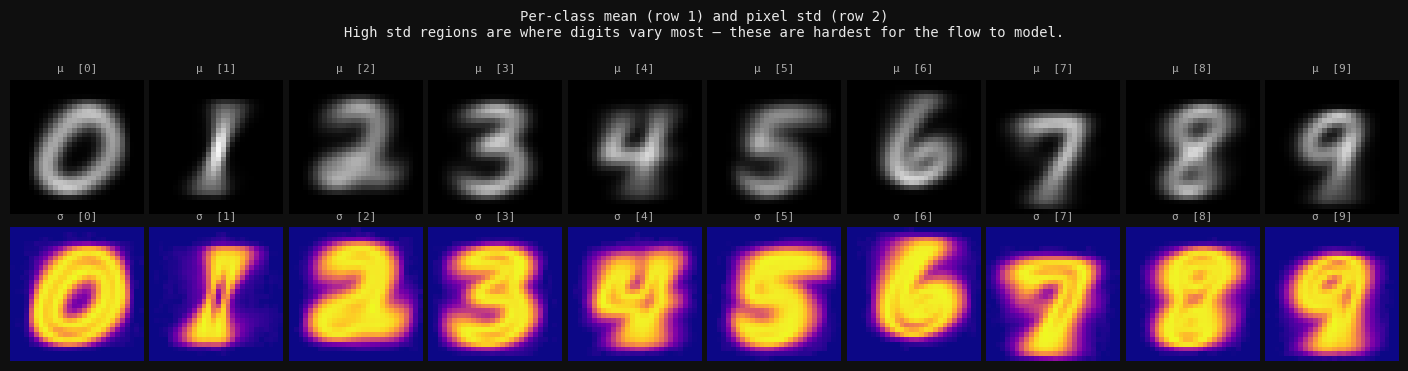

In [27]:
# Compute mean and std image per class
# Use raw dataset tensors for speed (already uint8, we normalise manually)
raw_data   = dataset.data.float() / 255.0          # (60000, 28, 28)
raw_labels = dataset.targets                        # (60000,)

class_means = []
class_stds  = []
for digit in range(10):
    mask = (raw_labels == digit)
    imgs = raw_data[mask]           # (N_digit, 28, 28)
    class_means.append(imgs.mean(0))
    class_stds.append(imgs.std(0))

class_means = torch.stack(class_means).unsqueeze(1)   # (10, 1, 28, 28)
class_stds  = torch.stack(class_stds).unsqueeze(1)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for digit in range(10):
    # Mean
    ax = axes[0, digit]
    ax.imshow(class_means[digit, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'μ  [{digit}]', color='#aaaaaa', fontsize=8)

    # Std — use plasma for visibility
    ax = axes[1, digit]
    im = ax.imshow(class_stds[digit, 0].numpy(), cmap='plasma', vmin=0)
    ax.axis('off')
    ax.set_title(f'σ  [{digit}]', color='#aaaaaa', fontsize=8)

plt.suptitle(
    'Per-class mean (row 1) and pixel std (row 2)\n'
    'High std regions are where digits vary most — these are hardest for the flow to model.',
    color='#e8e8e8', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

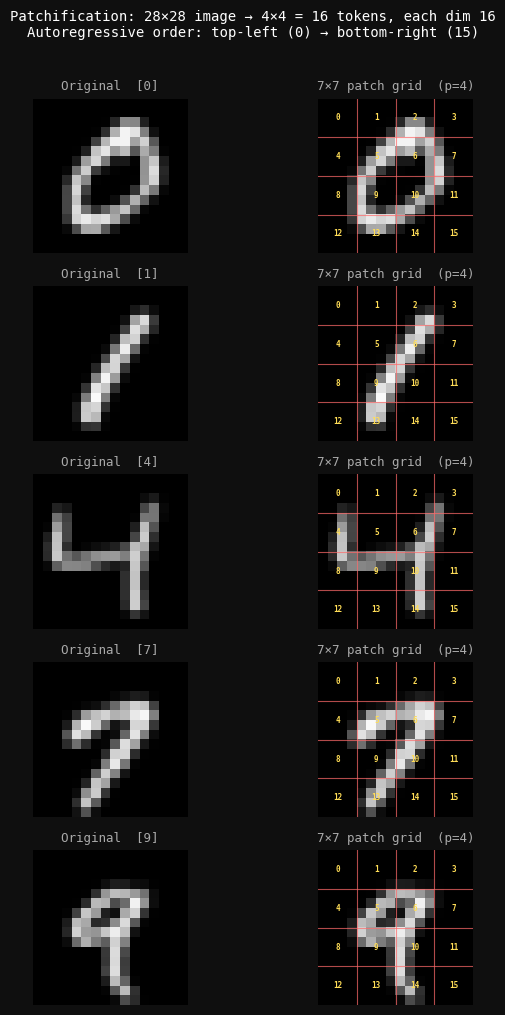

In [28]:
# Pick one image from each of five classes
demo_digits = [0, 1, 4, 7, 9]
demo_imgs   = []
for d in demo_digits:
    idx = (dataset.targets == d).nonzero(as_tuple=True)[0][0].item()
    demo_imgs.append(dataset[idx][0])   # (1, 28, 28) in [-1,1]

fig, axes = plt.subplots(len(demo_digits), 2, figsize=(7, 10))
fig.patch.set_facecolor('#0f0f0f')

patch_size = cfg.patch_size
grid_n     = cfg.img_size // patch_size   # 7

for row, (digit, img) in enumerate(zip(demo_digits, demo_imgs)):
    # Original image
    ax = axes[row, 0]
    ax.imshow(((img[0] + 1) / 2).numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Original  [{digit}]', color='#aaaaaa', fontsize=9)
    ax.axis('off')

    # Draw patch grid overlay on a copy
    ax2 = axes[row, 1]
    ax2.imshow(((img[0] + 1) / 2).numpy(), cmap='gray', vmin=0, vmax=1)
    for i in range(1, grid_n):
        ax2.axhline(i * patch_size - 0.5, color='#ff6b6b', linewidth=0.8, alpha=0.7)
        ax2.axvline(i * patch_size - 0.5, color='#ff6b6b', linewidth=0.8, alpha=0.7)
    # Number patches in raster order
    for r in range(grid_n):
        for c in range(grid_n):
            patch_idx = r * grid_n + c
            ax2.text(
                c * patch_size + patch_size/2 - 0.5,
                r * patch_size + patch_size/2 - 0.5,
                str(patch_idx), ha='center', va='center',
                fontsize=5.5, color='#ffdd57', fontweight='bold'
            )
    ax2.set_title(f'7×7 patch grid  (p={patch_size})', color='#aaaaaa', fontsize=9)
    ax2.axis('off')

plt.suptitle(
    f'Patchification: 28×28 image → {grid_n}×{grid_n} = {cfg.num_patches} tokens, '
    f'each dim {cfg.patch_dim}\n'
    f'Autoregressive order: top-left (0) → bottom-right ({cfg.num_patches-1})',
    color='#ffffff', fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

In [29]:
model = build_model(cfg, device=DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model architecture')
print(f'  Blocks           : {cfg.blocks}  (alternating identity / flip permutation)')
print(f'  Layers per block : {cfg.layers_per_block}')
print(f'  Transformer dim  : {cfg.channels}')
print(f'  NVP mode         : {cfg.nvp}')
print(f'  Num classes      : {cfg.num_classes}')
print()
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Model architecture
  Blocks           : 4  (alternating identity / flip permutation)
  Layers per block : 4
  Transformer dim  : 128
  NVP mode         : True
  Num classes      : 10

Total parameters     : 3,210,880
Trainable parameters : 3,210,880


In [30]:
trainer = Trainer(model, train_loader, cfg, device=DEVICE)
history = trainer.train()

-------------------------- TARFlow Training --------------------------
  Device         : cpu
  Parameters     : 3,210,880
  Epochs         : 50
  Batch size     : 256
  Noise type     : gaussian  (σ=0.05)
  Label drop     : 0.1

  Ep [  1/50] Step [ 200/234] loss=-0.3820  nll=0.4646  logdet=0.8466  lr=8.56e-05

Epoch   1/50 | loss=-0.4962 | nll=0.4673 | logdet=0.9635 | block_norms=[3.0042 2.9891 1.7406 1.0523]

  Ep [  2/50] Step [ 200/234] loss=-1.3989  nll=0.4801  logdet=1.8790  lr=9.99e-05

Epoch   2/50 | loss=-1.4223 | nll=0.4804 | logdet=1.9027 | block_norms=[2.8468 1.8080 1.0357 0.9173]

  Ep [  3/50] Step [ 200/234] loss=-1.6477  nll=0.4873  logdet=2.1351  lr=9.97e-05

Epoch   3/50 | loss=-1.6567 | nll=0.4878 | logdet=2.1445 | block_norms=[2.9511 1.0744 0.8730 0.9738]

  Ep [  4/50] Step [ 200/234] loss=-1.7453  nll=0.4929  logdet=2.2382  lr=9.92e-05

Epoch   4/50 | loss=-1.7499 | nll=0.4931 | logdet=2.2431 | block_norms=[2.3455 0.8039 0.7418 0.9863]

  Ep [  5/50] Step [ 200/2

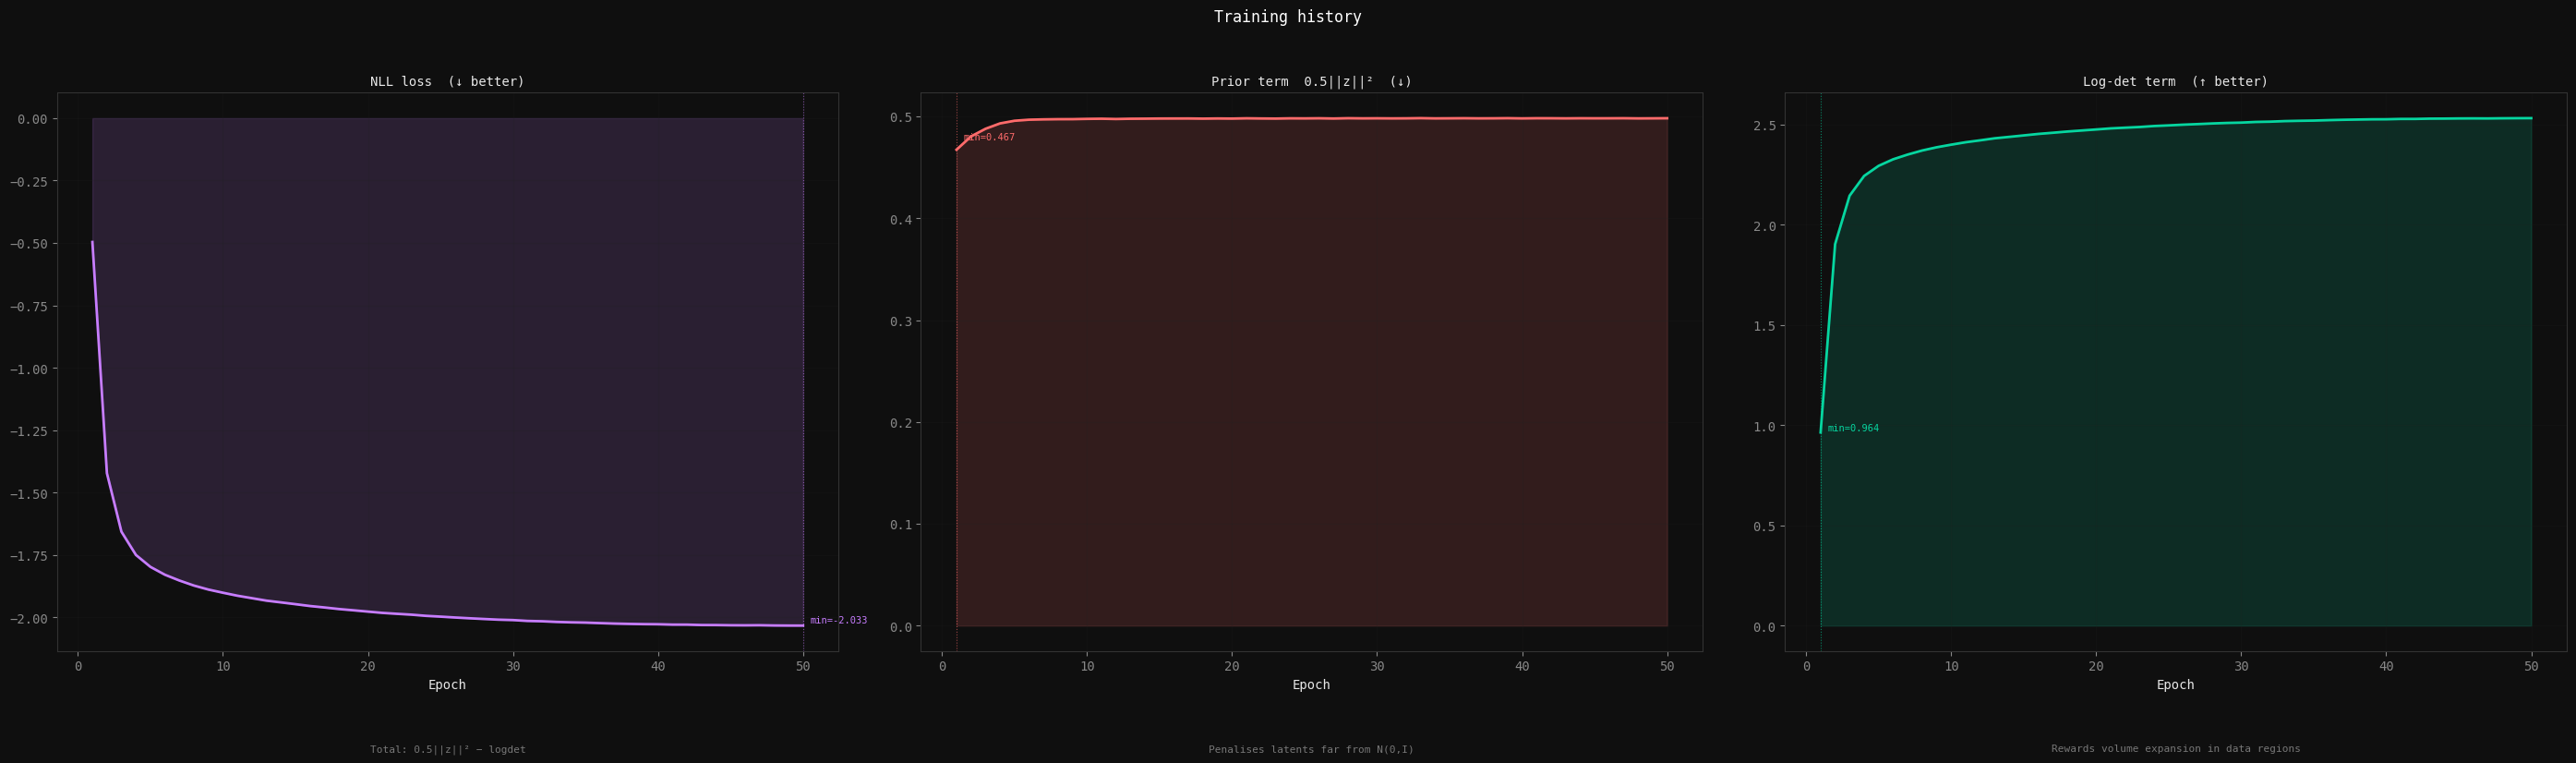

Final loss   : -2.0330
Final nll    : 0.4982
Final logdet : 2.5312


In [45]:
epochs_axis = list(range(1, len(history['loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(28, 8))
fig.patch.set_facecolor('#0f0f0f')

plot_specs = [
    ('loss',    '#c77dff', 'NLL loss  (↓ better)',            'Total: 0.5||z||² − logdet'),
    ('nll',     '#ff6b6b', 'Prior term  0.5||z||²  (↓)',      'Penalises latents far from N(0,I)'),
    ('logdet',  '#06d6a0', 'Log-det term  (↑ better)',        'Rewards volume expansion in data regions'),
]

for ax, (key, color, title, subtitle) in zip(axes, plot_specs):
    ax.plot(epochs_axis, history[key], color=color, linewidth=2)
    ax.fill_between(epochs_axis, history[key], alpha=0.15, color=color)
    ax.set_title(title, color='#e8e8e8', fontsize=10, pad=6)
    ax.set_xlabel('Epoch')
    ax.text(0.5, -0.18, subtitle, transform=ax.transAxes,
            ha='center', color='#777777', fontsize=8)
    ax.grid(alpha=0.2)
    min_val = min(history[key])
    min_ep  = history[key].index(min_val) + 1
    ax.axvline(min_ep, color=color, linewidth=0.8, linestyle=':', alpha=0.6)
    ax.annotate(f'min={min_val:.3f}', xy=(min_ep, min_val),
                xytext=(min_ep + 0.5, min_val + 0.01),
                color=color, fontsize=7.5)

plt.suptitle('Training history', color='#ffffff', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print(f'Final loss   : {history["loss"][-1]:.4f}')
print(f'Final nll    : {history["nll"][-1]:.4f}')
print(f'Final logdet : {history["logdet"][-1]:.4f}')

In [32]:
model.load_state_dict(torch.load('runs/model.pth', map_location=DEVICE))
model.eval()

print(f'Model loaded  — {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Device        — {DEVICE}')

Model loaded  — 3,210,880 parameters
Device        — cpu


In [ ]:
model.eval()

# Default SampleConfig
base_cfg = SampleConfig(
    guidance          = 2.0,
    guide_what        = 'ab',
    annealed_guidance = False,
    attn_temp         = 1.0,
    denoise           = False,
    noise_std         = cfg.noise_std,   
    denoise_steps     = 1,
    clip_output       = True,
)

sampler = Sampler(model, base_cfg)

# Labels: one of each digit, repeated — 40 samples, 4 per class
LABELS_40   = list(range(10)) * 4
LABELS_10   = list(range(10))
N_PLAIN     = 40
GUIDANCE_W  = 2.0

print('Sampler ready.')
print(f'Device         : {sampler.device}')
print(f'Num patches    : {sampler._num_patches}')
print(f'Patch dim      : {sampler._patch_dim}')

Sampler ready.
Device         : cpu
Num patches    : 16
Patch dim      : 16


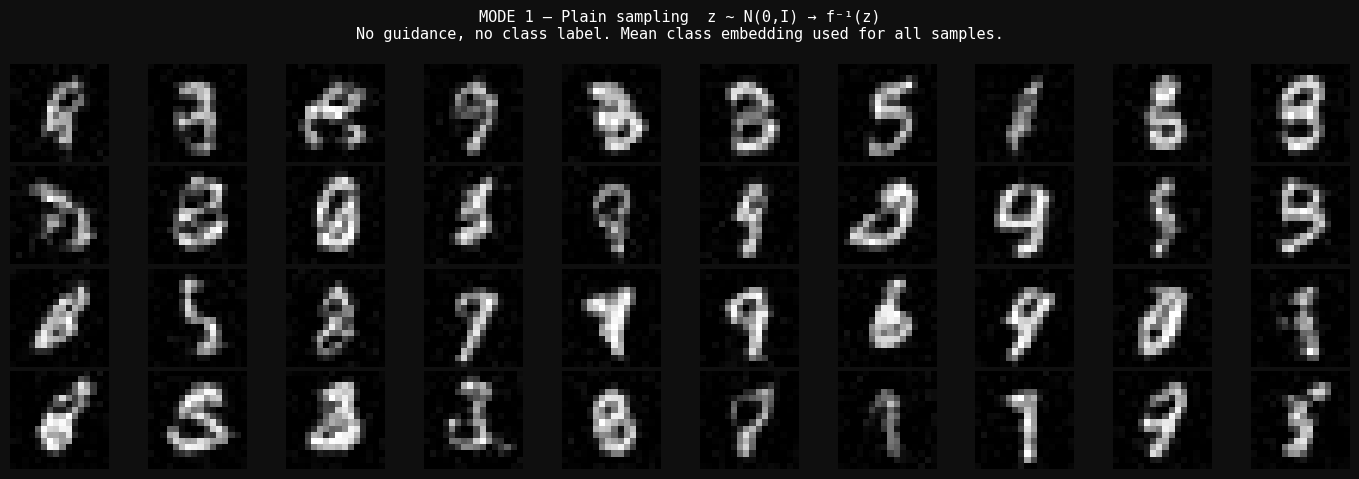

In [46]:
plain_samples = sampler.sample_plain(n=N_PLAIN)

show_grid(
    plain_samples,
    nrow=10,
    figsize=(14, 4.5),
    suptitle='MODE 1 — Plain sampling  z ~ N(0,I) → f⁻¹(z)\n'
             'No guidance, no class label. Mean class embedding used for all samples.',
)

In [35]:
def _apply_label_drop(y, drop_prob):
    mask = (torch.rand(y.size(0), device=y.device) < drop_prob).int()
    return (1 - mask) * y - mask

In [36]:
model.eval()
x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch + 0.05 * torch.randn_like(x_batch)
y_batch = _apply_label_drop(y_batch, 0.1)

with torch.no_grad():
    z, outputs, logdets = model(x_batch, y_batch)

print(f'z mean={z.mean():.4f}  std={z.std():.4f}')
print(f'logdets mean={logdets.mean():.4f}  min={logdets.min():.4f}  max={logdets.max():.4f}')
print(f'loss={model.get_loss(z, logdets):.4f}')

for i, out in enumerate(outputs):
    print(f'Block {i+1} z mean={out.mean():.4f}  std={out.std():.4f}  norm={out.pow(2).mean():.4f}')

z mean=-0.0029  std=0.9983
logdets mean=2.5294  min=2.2574  max=2.8153
loss=-2.0311
Block 1 z mean=-0.0134  std=0.7893  norm=0.6232
Block 2 z mean=0.0556  std=0.5293  norm=0.2833
Block 3 z mean=0.2066  std=0.5976  norm=0.3998
Block 4 z mean=-0.0029  std=0.9983  norm=0.9965


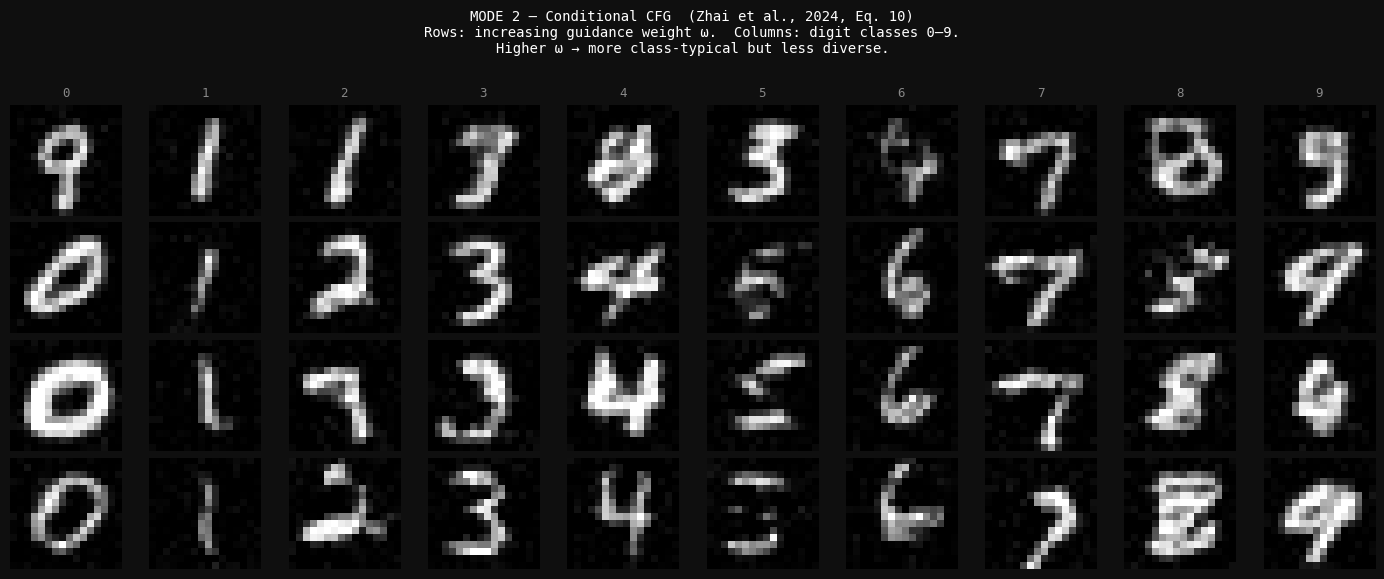

In [47]:
guidance_weights = [0.0, 1.0, 2.0, 3.0]
n_per_class      = 1
labels_10        = list(range(10)) * n_per_class

fig, axes = plt.subplots(
    len(guidance_weights), 10,
    figsize=(14, 5.5)
)
fig.patch.set_facecolor('#0f0f0f')

for row, w in enumerate(guidance_weights):
    samples = sampler.sample_conditional(labels=labels_10, guidance=w)
    imgs    = ((samples.cpu() + 1) / 2).clamp(0, 1)

    for col in range(10):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(col), color='#888888', fontsize=9)

    axes[row, 0].set_ylabel(f'ω = {w}', color='#c77dff', fontsize=9, rotation=0,
                             labelpad=38, va='center')

plt.suptitle(
    'MODE 2 — Conditional CFG  (Zhai et al., 2024, Eq. 10)\n'
    'Rows: increasing guidance weight ω.  Columns: digit classes 0–9.\n'
    'Higher ω → more class-typical but less diverse.',
    color='#ffffff', fontsize=10, y=1.03
)
plt.tight_layout(pad=0.5)
plt.show()

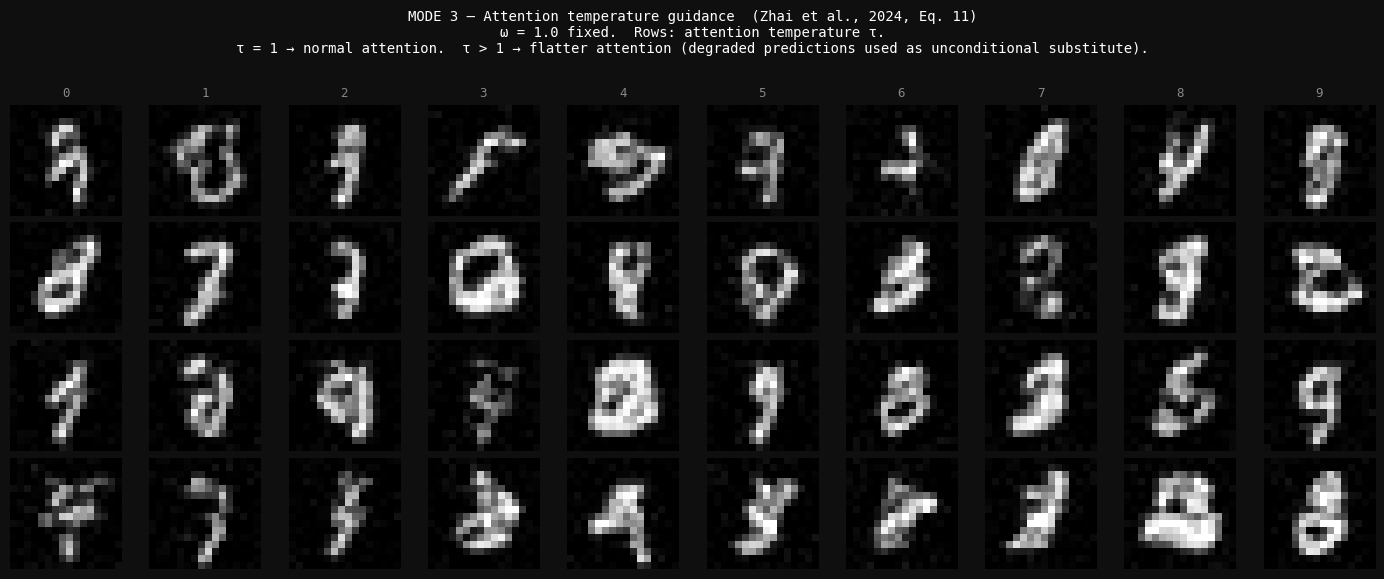

In [48]:
temps    = [1.0, 1.2, 1.5, 2.0]
guidance = 1.0

fig, axes = plt.subplots(len(temps), 10, figsize=(14, 5.5))
fig.patch.set_facecolor('#0f0f0f')

for row, tau in enumerate(temps):
    samples = sampler.sample_temperature_guided(n=10, guidance=guidance, attn_temp=tau)
    imgs    = ((samples.cpu() + 1) / 2).clamp(0, 1)

    for col in range(10):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(col), color="#888888", fontsize=9)

    axes[row, 0].set_ylabel(f'τ = {tau}', color='#06d6a0', fontsize=9,
                             rotation=0, labelpad=38, va='center')

plt.suptitle(
    'MODE 3 — Attention temperature guidance  (Zhai et al., 2024, Eq. 11)\n'
    f'ω = {guidance} fixed.  Rows: attention temperature τ.\n'
    'τ = 1 → normal attention.  τ > 1 → flatter attention (degraded predictions used as unconditional substitute).',
    color='#ffffff', fontsize=10, y=1.03
)
plt.tight_layout(pad=0.5)
plt.show()

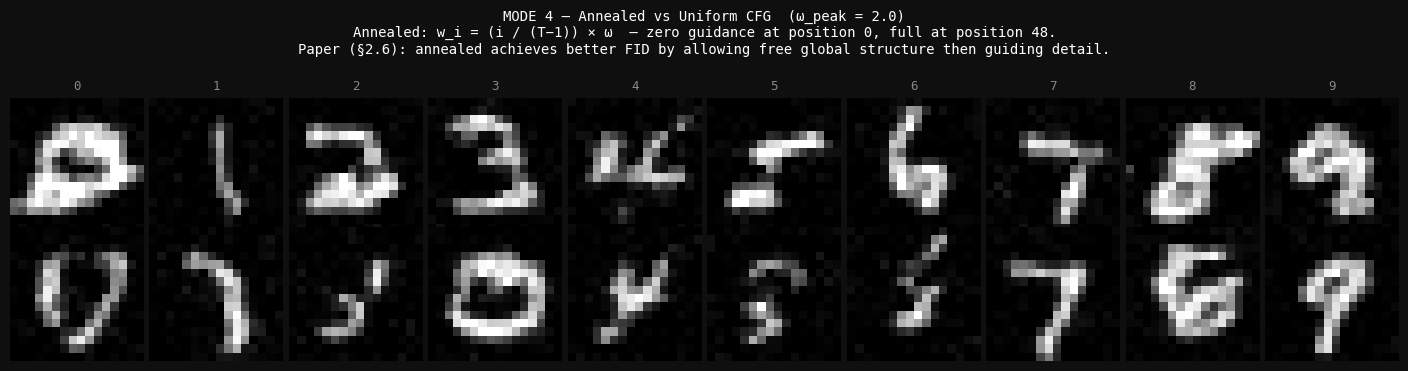

In [49]:
labels_row = list(range(10))

uniform_samples  = sampler.sample_conditional(labels=labels_row, guidance=GUIDANCE_W)
annealed_samples = sampler.sample_annealed(labels=labels_row,    guidance=GUIDANCE_W)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for col in range(10):
    for row, (samples, label) in enumerate([
        (uniform_samples,  'Uniform guidance'),
        (annealed_samples, 'Annealed guidance'),
    ]):
        img = ((samples[col].cpu() + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(str(col), color='#888888', fontsize=9)

axes[0, 0].set_ylabel('Uniform\nω = const', color='#ff9f1c', fontsize=8,
                       rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('Annealed\nω grows', color='#ff9f1c', fontsize=8,
                       rotation=0, labelpad=50, va='center')

plt.suptitle(
    f'MODE 4 — Annealed vs Uniform CFG  (ω_peak = {GUIDANCE_W})\n'
    'Annealed: w_i = (i / (T−1)) × ω  — zero guidance at position 0, full at position 48.\n'
    'Paper (§2.6): annealed achieves better FID by allowing free global structure then guiding detail.',
    color='#ffffff', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

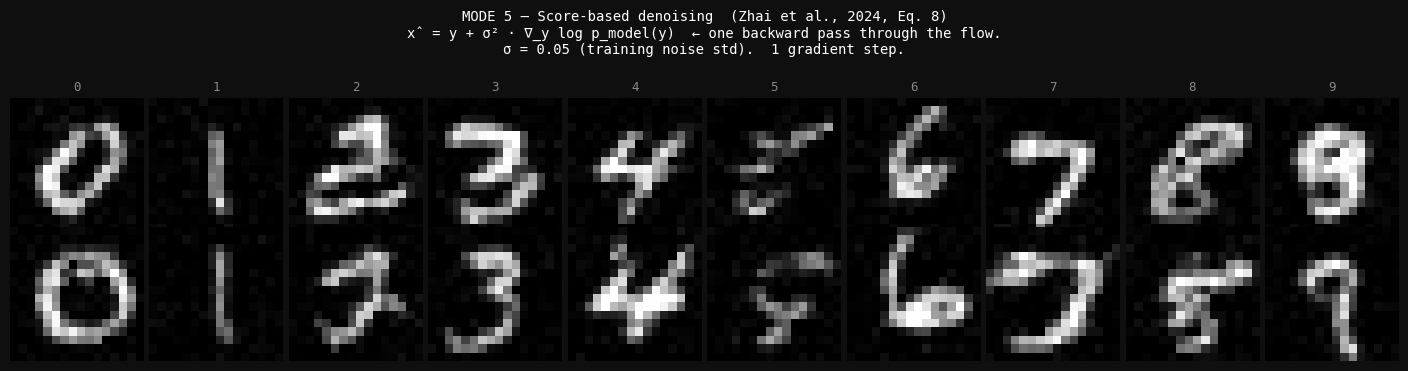

Mean absolute denoising correction : 0.2514
Max  absolute denoising correction : 2.0000


In [50]:
labels_row  = list(range(10))

raw_samples      = sampler.sample_conditional(labels=labels_row, guidance=GUIDANCE_W)
denoised_samples = sampler.sample_denoised(n=10, labels=labels_row,
                                           guidance=GUIDANCE_W,
                                           noise_std=cfg.noise_std)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for col in range(10):
    for row, (samples, label) in enumerate([
        (raw_samples,      'Raw'),
        (denoised_samples, 'Denoised'),
    ]):
        img = ((samples[col].cpu() + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(str(col), color='#888888', fontsize=9)

axes[0, 0].set_ylabel('Raw\nf⁻¹(z)', color='#ff6b6b', fontsize=8,
                       rotation=0, labelpad=38, va='center')
axes[1, 0].set_ylabel('Denoised\nTweedie', color='#06d6a0', fontsize=8,
                       rotation=0, labelpad=38, va='center')

plt.suptitle(
    'MODE 5 — Score-based denoising  (Zhai et al., 2024, Eq. 8)\n'
    'x̂ = y + σ² · ∇_y log p_model(y)  ← one backward pass through the flow.\n'
    f'σ = {cfg.noise_std} (training noise std).  1 gradient step.',
    color='#ffffff', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

# Pixel-level difference
diff = (denoised_samples - raw_samples).abs().cpu()
print(f'Mean absolute denoising correction : {diff.mean():.4f}')
print(f'Max  absolute denoising correction : {diff.max():.4f}')

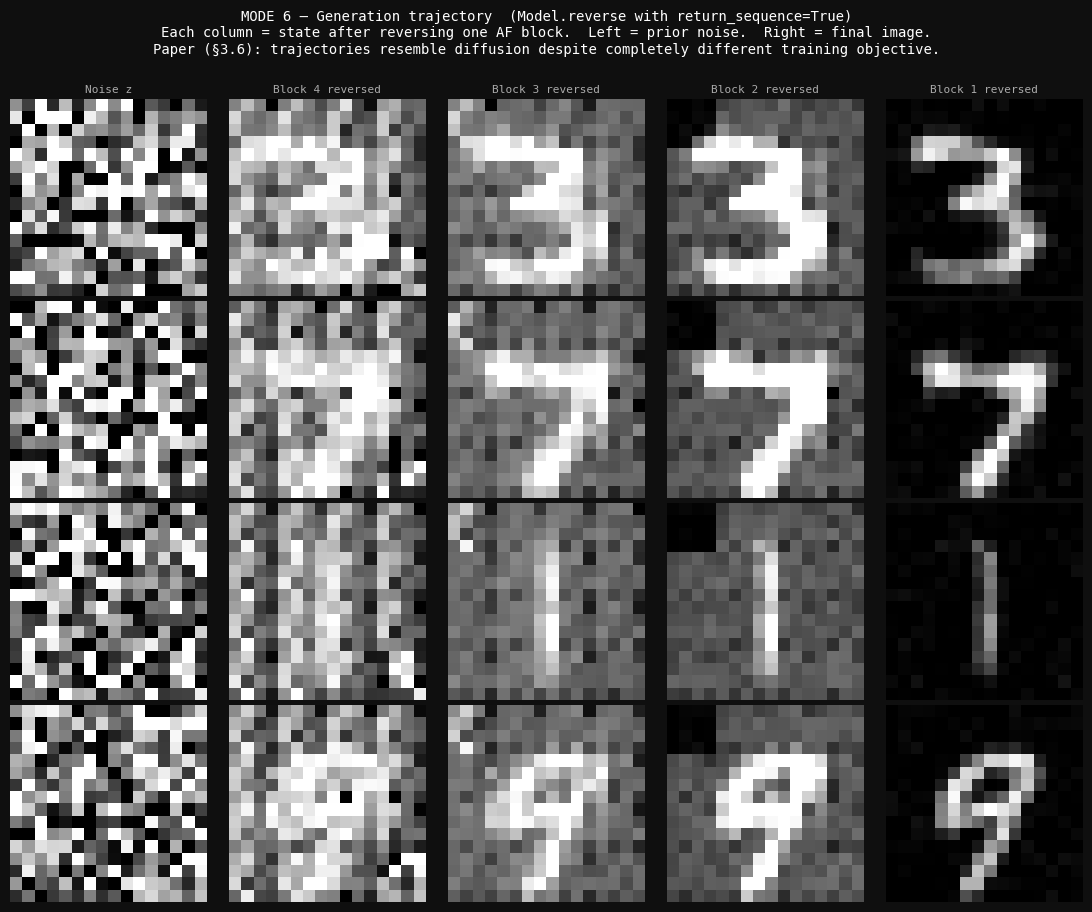

Number of trajectory frames : 5  (1 noise + 4 blocks)


In [52]:
n_traj   = 4
traj_labels = [3, 7, 1, 9]

frames = sampler.sample_trajectory(n=n_traj, labels=traj_labels, guidance=GUIDANCE_W)
# frames is a list of length (num_blocks + 1), each tensor (n_traj, 1, 28, 28)

n_steps = len(frames)
step_labels = ['Noise z'] + [f'Block {cfg.blocks - i} reversed' for i in range(cfg.blocks)]

fig, axes = plt.subplots(n_traj, n_steps, figsize=(n_steps * 2.2, n_traj * 2.2))
fig.patch.set_facecolor('#0f0f0f')

for row in range(n_traj):
    for col, frame in enumerate(frames):
        ax  = axes[row, col]
        img = ((frame[row].cpu() + 1) / 2).clamp(0, 1)
        ax.imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(step_labels[col], color='#aaaaaa', fontsize=8, pad=4)
    axes[row, 0].set_ylabel(f'digit {traj_labels[row]}', color='#c77dff',
                             fontsize=8, rotation=0, labelpad=40, va='center')

# Draw arrows between columns
plt.suptitle(
    'MODE 6 — Generation trajectory  (Model.reverse with return_sequence=True)\n'
    'Each column = state after reversing one AF block.  Left = prior noise.  Right = final image.\n'
    'Paper (§3.6): trajectories resemble diffusion despite completely different training objective.',
    color='#ffffff', fontsize=10, y=1.02
)
plt.tight_layout(pad=0.4)
plt.show()

print(f'Number of trajectory frames : {len(frames)}  (1 noise + {cfg.blocks} blocks)')

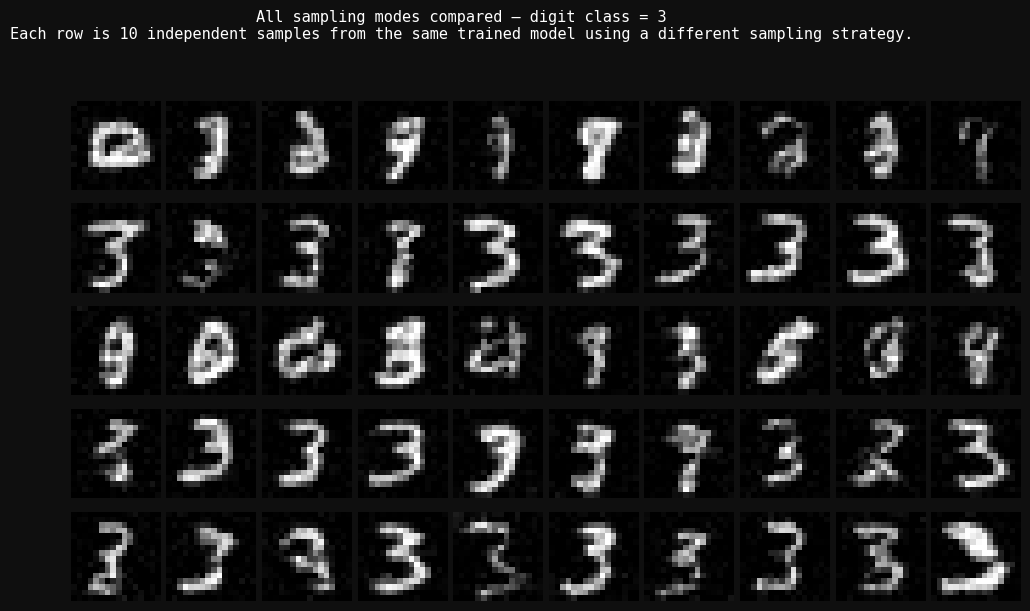

In [53]:
TARGET_DIGIT = 3
N_COMPARE    = 10
labels_same  = [TARGET_DIGIT] * N_COMPARE

modes = [
    ('Mode 1 — Plain',                   sampler.sample_plain(n=N_COMPARE)),
    ('Mode 2 — Conditional CFG (ω=2)',   sampler.sample_conditional(labels_same, guidance=2.0)),
    ('Mode 3 — Temp-guided (τ=1.5,ω=1)', sampler.sample_temperature_guided(N_COMPARE, guidance=1.0, attn_temp=1.5)),
    ('Mode 4 — Annealed CFG (ω=2)',      sampler.sample_annealed(labels_same, guidance=2.0)),
    ('Mode 5 — Denoised (ω=2, σ=0.05)', sampler.sample_denoised(N_COMPARE, labels_same, guidance=2.0)),
]

mode_colors = ['#888888', '#c77dff', '#06d6a0', '#ff9f1c', '#ff6b6b']

fig, axes = plt.subplots(len(modes), N_COMPARE, figsize=(14, 6.5))
fig.patch.set_facecolor('#0f0f0f')

for row, ((mode_name, samples), color) in enumerate(zip(modes, mode_colors)):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    for col in range(N_COMPARE):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        # Colour-coded left border per mode
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[row, 0].set_ylabel(mode_name, color=color, fontsize=8,
                             rotation=0, labelpad=160, va='center')

plt.suptitle(
    f'All sampling modes compared — digit class = {TARGET_DIGIT}\n'
    'Each row is 10 independent samples from the same trained model using a different sampling strategy.',
    color='#ffffff', fontsize=11, y=1.02
)
plt.subplots_adjust(left=0.22, wspace=0.05, hspace=0.15)
plt.show()

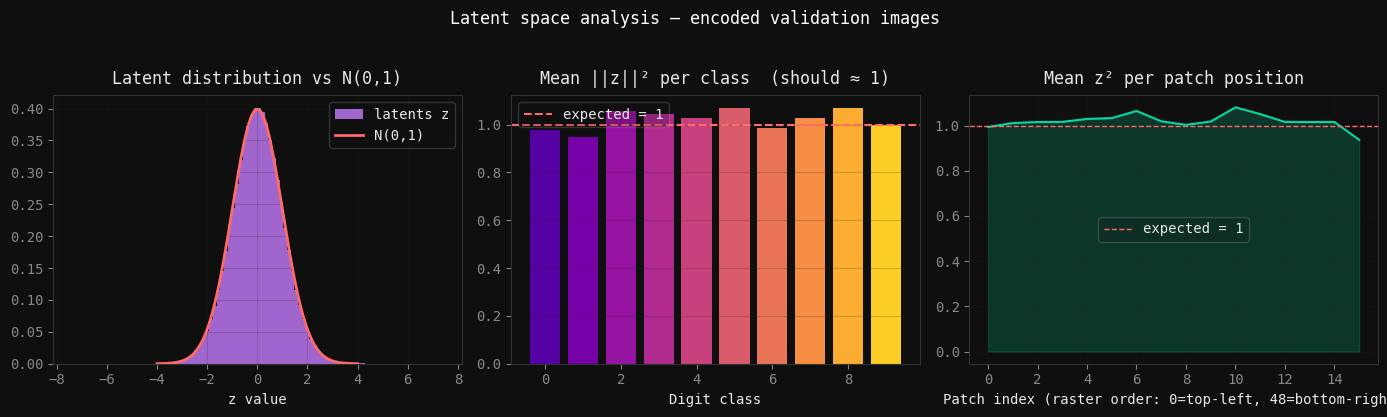

Latent mean  : 0.0051  (should be ≈ 0)
Latent std   : 1.0101   (should be ≈ 1)
Latent shape : torch.Size([2560, 16, 16])


In [54]:
model.eval()
all_z, all_labels_list = [], []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(val_loader):
        if batch_idx >= 10:   # 10 batches × 128 = ~1280 images
            break
        x = x.to(DEVICE)
        # Add the same noise as training so the encoding is in-distribution
        x_noisy = x + cfg.noise_std * torch.randn_like(x)
        z, _, _ = model(x_noisy)
        all_z.append(z.cpu())
        all_labels_list.append(y)

all_z      = torch.cat(all_z,           dim=0)   # (N, 49, 16)
all_labels_t = torch.cat(all_labels_list, dim=0)

# Flatten to (N, 49*16) for statistics
z_flat = all_z.reshape(all_z.shape[0], -1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0f0f0f')

# --- Histogram of all latent values vs N(0,1) ---
ax = axes[0]
z_vals = z_flat.numpy().flatten()
ax.hist(z_vals, bins=100, density=True, color='#c77dff', alpha=0.8, label='latents z')
xs = np.linspace(-4, 4, 300)
ax.plot(xs, np.exp(-0.5 * xs**2) / np.sqrt(2 * np.pi),
        color='#ff6b6b', linewidth=2, label='N(0,1)')
ax.set_title('Latent distribution vs N(0,1)', color='#e8e8e8', pad=8)
ax.set_xlabel('z value')
ax.legend(framealpha=0.2)
ax.grid(alpha=0.2)

# --- Per-class mean latent norm ---
ax = axes[1]
class_norms = []
for digit in range(10):
    mask = (all_labels_t == digit)
    class_norms.append(z_flat[mask].pow(2).mean().item())
bar_colors = plt.cm.plasma(np.linspace(0.15, 0.9, 10))
ax.bar(range(10), class_norms, color=bar_colors)
ax.axhline(1.0, color='#ff6b6b', linewidth=1.5, linestyle='--', label='expected = 1')
ax.set_title('Mean ||z||² per class  (should ≈ 1)', color='#e8e8e8', pad=8)
ax.set_xlabel('Digit class')
ax.legend(framealpha=0.2)
ax.grid(axis='y', alpha=0.2)

# --- Latent variance across patch positions ---
ax = axes[2]
patch_var = all_z.pow(2).mean(dim=[0, 2]).numpy()   # (49,) mean over batch and channel
ax.plot(range(len(patch_var)), patch_var, color='#06d6a0', linewidth=1.5)
ax.fill_between(range(len(patch_var)), patch_var, alpha=0.2, color='#06d6a0')
ax.axhline(1.0, color='#ff6b6b', linewidth=1, linestyle='--', label='expected = 1')
ax.set_title('Mean z² per patch position', color='#e8e8e8', pad=8)
ax.set_xlabel('Patch index (raster order: 0=top-left, 48=bottom-right)')
ax.legend(framealpha=0.2)
ax.grid(alpha=0.2)

plt.suptitle('Latent space analysis — encoded validation images', color='#ffffff', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print(f'Latent mean  : {z_flat.mean():.4f}  (should be ≈ 0)')
print(f'Latent std   : {z_flat.std():.4f}   (should be ≈ 1)')
print(f'Latent shape : {all_z.shape}')

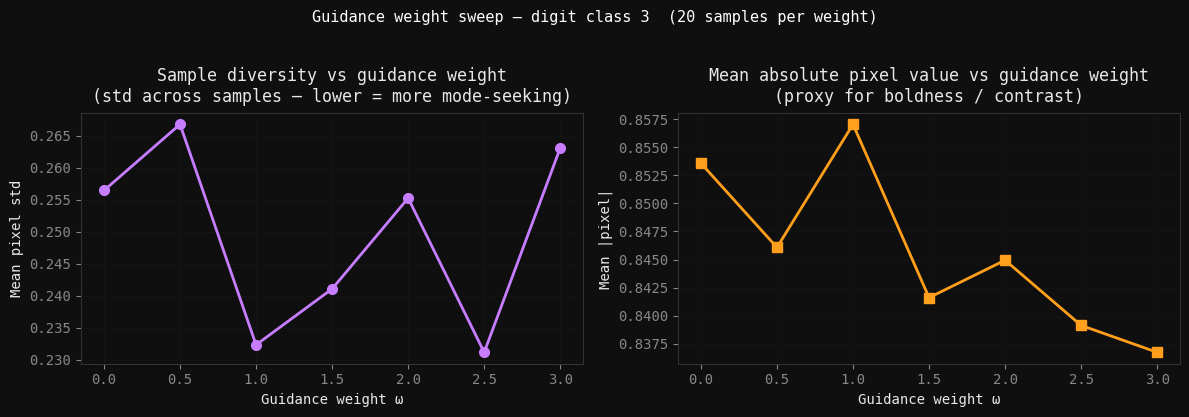

In [55]:
guidance_sweep = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
n_per_w        = 20
labels_w       = [3] * n_per_w   # all digit 3

mean_stds   = []
mean_norms  = []

for w in guidance_sweep:
    samples = sampler.sample_conditional(labels=labels_w, guidance=w)
    # Diversity: mean pixel std across samples
    mean_stds.append(samples.std(dim=0).mean().item())
    # Sharpness proxy: mean absolute value (bolder digits = higher values)
    mean_norms.append(samples.abs().mean().item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
ax.plot(guidance_sweep, mean_stds, 'o-', color='#c77dff', linewidth=2, markersize=7)
ax.set_title('Sample diversity vs guidance weight\n(std across samples — lower = more mode-seeking)',
             color='#e8e8e8', pad=8)
ax.set_xlabel('Guidance weight ω')
ax.set_ylabel('Mean pixel std')
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(guidance_sweep, mean_norms, 's-', color='#ff9f1c', linewidth=2, markersize=7)
ax.set_title('Mean absolute pixel value vs guidance weight\n(proxy for boldness / contrast)',
             color='#e8e8e8', pad=8)
ax.set_xlabel('Guidance weight ω')
ax.set_ylabel('Mean |pixel|')
ax.grid(alpha=0.25)

plt.suptitle(f'Guidance weight sweep — digit class 3  ({n_per_w} samples per weight)',
             color='#ffffff', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()